# 📈 SalesPulse Forecaster
## LSTM-Based Sales Forecasting on Global Superstore Data
**Author:** Venkatraman R — Data Science & AI Engineer  
**Tools:** Python · TensorFlow/Keras · SQL · Pandas · Matplotlib  
**Dataset:** Global Superstore (2011–2014) · 51,290 records  

---
### 🗂️ Notebook Structure
| Phase | Section |
|-------|---------|
| 1 | Data Loading & SQL Analysis |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Preprocessing for LSTM |
| 4 | LSTM Model Architecture |
| 5 | Training & Evaluation |
| 6 | Sales Forecasting (Next 12 Months) |
| 7 | Results & Business Insights |


---
## 📦 Phase 1 — Data Loading & SQL Analysis

In [1]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

from sqlalchemy import create_engine, text
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ── Plot Style ──
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#8B949E',
    'ytick.color':      '#8B949E',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D',
    'font.family':      'DejaVu Sans',
})
GOLD = '#D4AF37'
BLUE = '#58A6FF'
GREEN = '#3FB950'
RED  = '#F85149'

print("✅ Libraries loaded | TensorFlow:", tf.__version__)


I0000 00:00:1781217104.282241    1164 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781217104.282885    1164 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781217104.335941    1164 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781217105.592150    1164 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781217105.592564    1164 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ Libraries loaded | TensorFlow: 2.21.0


In [2]:
# ── Load Dataset ──
df = pd.read_csv('../data/GlobalSuperstoreData.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Date Range:", df['order_date'].min().date(), "→", df['order_date'].max().date())
print("\nSample:")
df.head()


Shape: (51290, 5)
Columns: ['order_date', 'segment', 'market', 'sales', 'profit']
Date Range: 2011-01-01 → 2014-12-31

Sample:


,order_date,segment,market,sales,profit
0,2012-07-31,Consumer,US,2309.650,762.1845
1,2013-02-05,Corporate,APAC,3709.395,-288.7650
2,2013-10-17,Consumer,APAC,5175.171,919.9710
3,2013-01-28,Home Office,EU,2892.510,-96.5400
4,2013-11-05,Consumer,Africa,2832.960,311.5200


In [3]:
# ── Load into SQLite & Run SQL Queries ──
engine = create_engine('sqlite:///../data/superstore.db')
df.to_sql('sales', engine, if_exists='replace', index=False)
print("✅ Data loaded into SQLite — table: sales")


✅ Data loaded into SQLite — table: sales


In [4]:
# ── SQL Query 1: Monthly Sales Aggregation ──
q1 = '''
    SELECT 
        strftime('%Y-%m', order_date) AS month,
        ROUND(SUM(sales), 2)          AS total_sales,
        ROUND(SUM(profit), 2)         AS total_profit,
        COUNT(*)                      AS order_count
    FROM sales
    GROUP BY month
    ORDER BY month
'''
monthly = pd.read_sql(text(q1), engine)
monthly['month'] = pd.to_datetime(monthly['month'])
print("Monthly records:", len(monthly))
monthly.head(10)


Monthly records: 48


,month,total_sales,total_profit,order_count
0,2011-01-01,98898.49,8321.80,433
1,2011-02-01,91152.16,12417.91,378
2,2011-03-01,145729.37,15303.57,539
3,2011-04-01,116915.76,12902.32,564
4,2011-05-01,146747.84,12183.83,566
5,2011-06-01,215207.38,23415.25,917
6,2011-07-01,115510.42,5585.00,495
7,2011-08-01,207581.49,23713.67,878
8,2011-09-01,290214.46,35776.88,1052
9,2011-10-01,199071.26,25963.42,774


In [5]:
# ── SQL Query 2: Sales by Market ──
q2 = '''
    SELECT 
        market,
        ROUND(SUM(sales), 2)  AS total_sales,
        ROUND(AVG(sales), 2)  AS avg_sales,
        ROUND(SUM(profit), 2) AS total_profit,
        COUNT(*)              AS orders
    FROM sales
    GROUP BY market
    ORDER BY total_sales DESC
'''
market_summary = pd.read_sql(text(q2), engine)
print(market_summary.to_string(index=False))


market  total_sales  avg_sales  total_profit  orders
  APAC   3585744.13     325.92     436000.05   11002
    EU   2938089.06     293.81     372829.74   10000
    US   2297200.86     229.86     286397.02    9994
 LATAM   2164605.17     210.28     221643.49   10294
  EMEA    806161.31     160.30      43897.97    5029
Africa    783773.21     170.87      88871.63    4587
Canada     66928.17     174.29      17817.39     384


In [6]:
# ── SQL Query 3: Sales by Segment ──
q3 = '''
    SELECT 
        segment,
        ROUND(SUM(sales), 2)  AS total_sales,
        ROUND(AVG(profit), 2) AS avg_profit,
        COUNT(*)              AS orders
    FROM sales
    GROUP BY segment
    ORDER BY total_sales DESC
'''
segment_summary = pd.read_sql(text(q3), engine)
print(segment_summary.to_string(index=False))


    segment  total_sales  avg_profit  orders
   Consumer   6507949.42       28.25   26518
  Corporate   3824697.52       28.60   15429
Home Office   2309854.97       29.65    9343


In [7]:
# ── SQL Query 4: Year-over-Year Growth ──
q4 = '''
    SELECT
        strftime('%Y', order_date) AS year,
        ROUND(SUM(sales), 2)       AS total_sales,
        ROUND(SUM(profit), 2)      AS total_profit
    FROM sales
    GROUP BY year
    ORDER BY year
'''
yoy = pd.read_sql(text(q4), engine)
yoy['sales_growth_%'] = yoy['total_sales'].pct_change().mul(100).round(2)
print(yoy.to_string(index=False))


year  total_sales  total_profit  sales_growth_%
2011   2259450.90     248940.81             NaN
2012   2677438.69     307415.28           18.50
2013   3405746.45     406935.23           27.20
2014   4299865.87     504165.97           26.25


---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

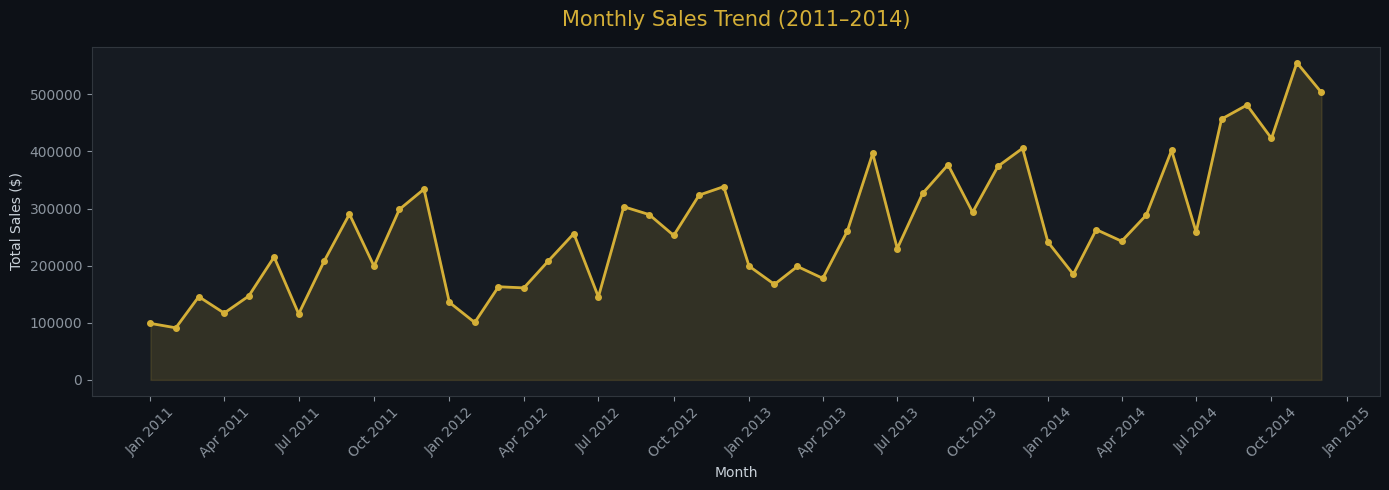

✅ Saved: assets/01_monthly_sales_trend.png


In [8]:
# ── Plot 1: Monthly Sales Trend ──
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['month'], monthly['total_sales'], color=GOLD, linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['month'], monthly['total_sales'], alpha=0.15, color=GOLD)
ax.set_title('Monthly Sales Trend (2011–2014)', fontsize=15, color=GOLD, pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/01_monthly_sales_trend.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Saved: assets/01_monthly_sales_trend.png")


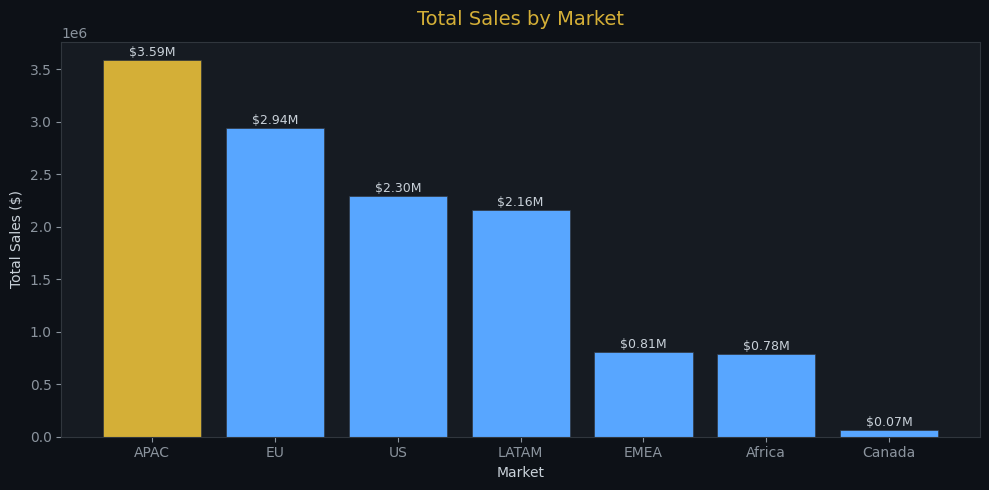

In [9]:
# ── Plot 2: Sales by Market (Bar Chart) ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = [GOLD if i == 0 else BLUE for i in range(len(market_summary))]
bars = ax.bar(market_summary['market'], market_summary['total_sales'], color=colors, edgecolor='#30363D', linewidth=0.5)
for bar, val in zip(bars, market_summary['total_sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=9, color='#C9D1D9')
ax.set_title('Total Sales by Market', fontsize=14, color=GOLD, pad=12)
ax.set_xlabel('Market'); ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../assets/02_sales_by_market.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


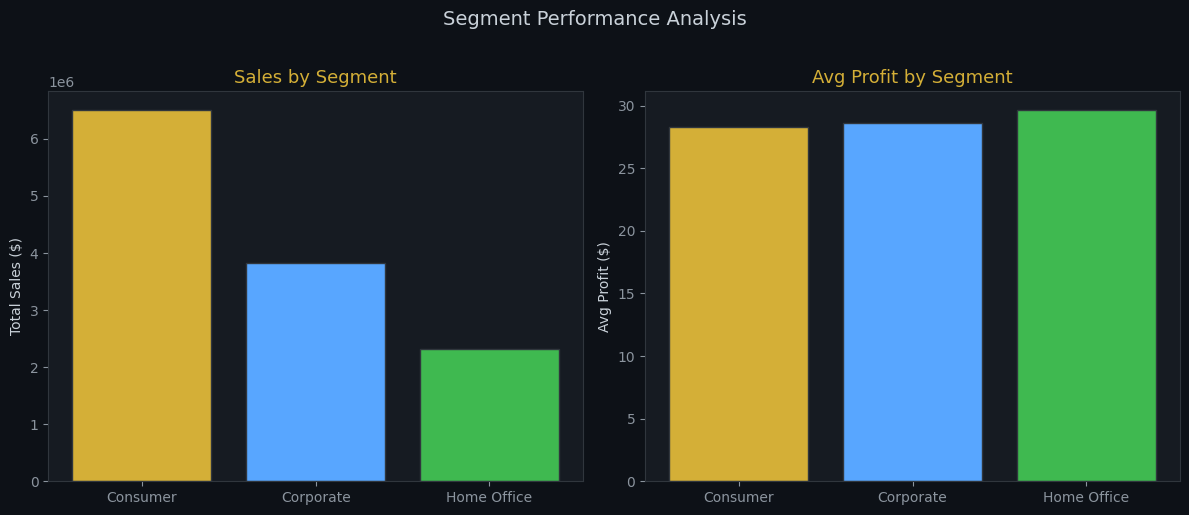

In [10]:
# ── Plot 3: Sales vs Profit by Segment ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seg_colors = [GOLD, BLUE, GREEN]

axes[0].bar(segment_summary['segment'], segment_summary['total_sales'], color=seg_colors, edgecolor='#30363D')
axes[0].set_title('Sales by Segment', fontsize=13, color=GOLD)
axes[0].set_ylabel('Total Sales ($)')

axes[1].bar(segment_summary['segment'], segment_summary['avg_profit'], color=seg_colors, edgecolor='#30363D')
axes[1].set_title('Avg Profit by Segment', fontsize=13, color=GOLD)
axes[1].set_ylabel('Avg Profit ($)')

plt.suptitle('Segment Performance Analysis', fontsize=14, color='#C9D1D9', y=1.02)
plt.tight_layout()
plt.savefig('../assets/03_segment_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


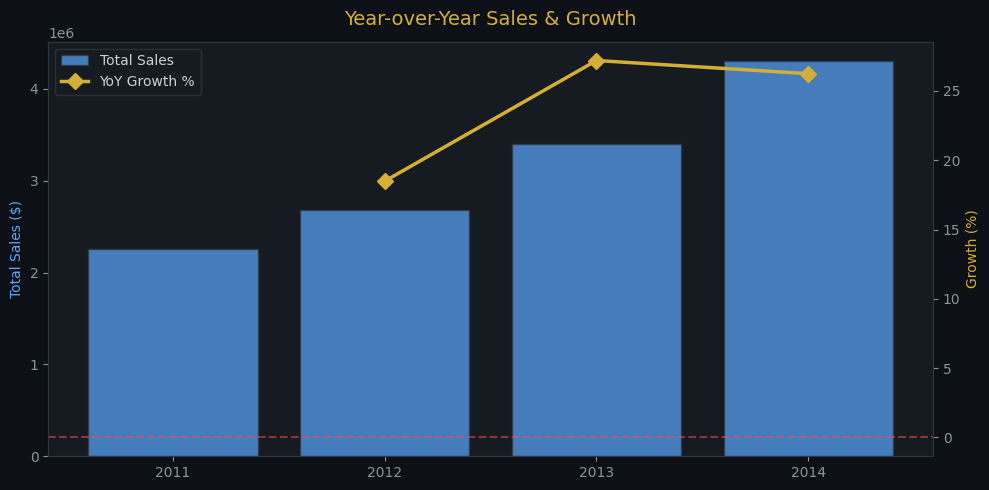

In [11]:
# ── Plot 4: Year-over-Year Sales Growth ──
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(yoy['year'], yoy['total_sales'], color=BLUE, alpha=0.7, label='Total Sales', edgecolor='#30363D')
ax2.plot(yoy['year'], yoy['sales_growth_%'], color=GOLD, linewidth=2.5, marker='D', markersize=8, label='YoY Growth %')

ax1.set_title('Year-over-Year Sales & Growth', fontsize=14, color=GOLD, pad=12)
ax1.set_ylabel('Total Sales ($)', color=BLUE)
ax2.set_ylabel('Growth (%)', color=GOLD)
ax2.axhline(0, color='#F85149', linestyle='--', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../assets/04_yoy_growth.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


---
## ⚙️ Phase 3 — Data Preprocessing for LSTM

In [12]:
# ── Prepare Time Series ──
ts = monthly[['month', 'total_sales']].copy()
ts = ts.set_index('month').sort_index()

print("Time series shape:", ts.shape)
print("\nFirst 5 rows:")
print(ts.head())

# ── Scale Data ──
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(ts[['total_sales']])
print("\n✅ Data scaled to [0, 1]")
print("Scaled shape:", scaled.shape)


Time series shape: (48, 1)

First 5 rows:
            total_sales
month                  
2011-01-01     98898.49
2011-02-01     91152.16
2011-03-01    145729.37
2011-04-01    116915.76
2011-05-01    146747.84

✅ Data scaled to [0, 1]
Scaled shape: (48, 1)


In [13]:
# ── Create Sequences for LSTM ──
def create_sequences(data, look_back=6):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

LOOK_BACK = 6   # use 6 months to predict next month

X, y = create_sequences(scaled, LOOK_BACK)

# ── Train/Test Split (80/20) ──
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ── Reshape for LSTM [samples, timesteps, features] ──
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

print(f"✅ Sequences created with look_back = {LOOK_BACK} months")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


✅ Sequences created with look_back = 6 months
X_train: (33, 6, 1) | y_train: (33,)
X_test:  (9, 6, 1)  | y_test:  (9,)


---
## 🧠 Phase 4 — LSTM Model Architecture

In [14]:
# ── Build LSTM Model ──
tf.random.set_seed(42)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


E0000 00:00:1781217107.985845    1164 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ Phase 5 — Training & Evaluation

In [15]:
# ── Train Model ──
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"Best epoch stopped at: {len(history.history['loss'])} epochs")


Epoch 1/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - loss: 0.1129 - mae: 0.2886

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.1017 - mae: 0.2748 - val_loss: 0.0787 - val_mae: 0.2253 - learning_rate: 0.0010


Epoch 2/150


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 0.0490 - mae: 0.1517

...


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0301 - mae: 0.1492 - val_loss: 0.0342 - val_mae: 0.1609 - learning_rate: 5.0000e-04


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 17.



✅ Training complete!
Best epoch stopped at: 32 epochs


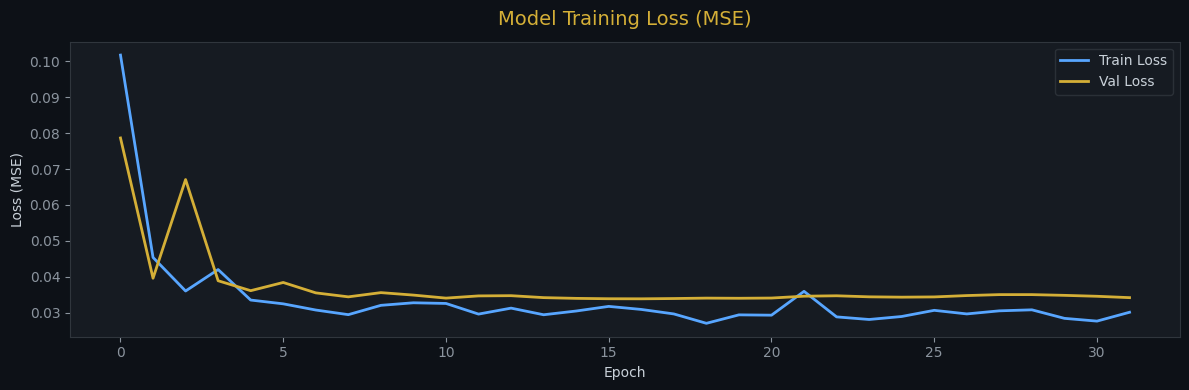

In [16]:
# ── Plot Training Loss ──
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history.history['loss'],     color=BLUE, linewidth=2, label='Train Loss')
ax.plot(history.history['val_loss'], color=GOLD, linewidth=2, label='Val Loss')
ax.set_title('Model Training Loss (MSE)', fontsize=14, color=GOLD, pad=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (MSE)')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/05_training_loss.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


In [17]:
# ── Evaluate on Test Set ──
y_pred_scaled = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=" * 40)
print("         📊 MODEL EVALUATION")
print("=" * 40)
print(f"  MAE  : ${mae:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


         📊 MODEL EVALUATION
  MAE  : $126,231.47
  RMSE : $151,234.10
  MAPE : 27.66%


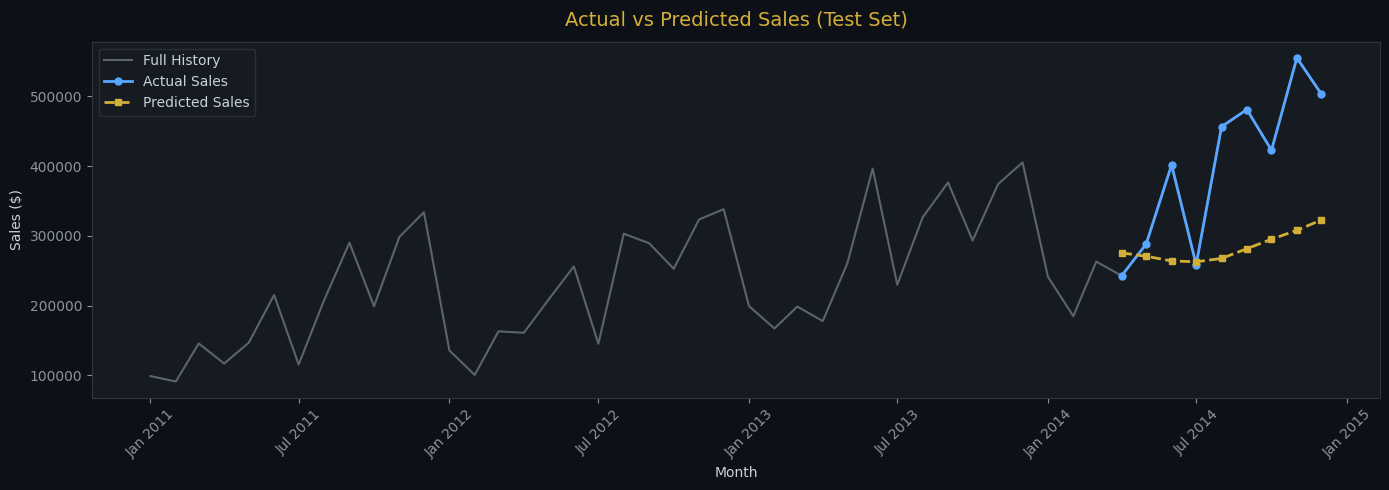

In [18]:
# ── Actual vs Predicted Plot ──
test_dates = ts.index[LOOK_BACK + split:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts['total_sales'], color='#8B949E', linewidth=1.5, label='Full History', alpha=0.6)
ax.plot(test_dates, y_true, color=BLUE,  linewidth=2, marker='o', markersize=5, label='Actual Sales')
ax.plot(test_dates, y_pred, color=GOLD,  linewidth=2, marker='s', markersize=5, linestyle='--', label='Predicted Sales')
ax.set_title('Actual vs Predicted Sales (Test Set)', fontsize=14, color=GOLD, pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Sales ($)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/06_actual_vs_predicted.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()


---
## 🔮 Phase 6 — Sales Forecasting (Next 12 Months)

In [19]:
# ── Forecast Next 12 Months ──
FORECAST_MONTHS = 12

last_sequence = scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)
predictions = []

for _ in range(FORECAST_MONTHS):
    pred = model.predict(last_sequence, verbose=0)[0][0]
    predictions.append(pred)
    last_sequence = np.append(last_sequence[:, 1:, :], [[[pred]]], axis=1)

forecast_values = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

# ── Build Forecast Dates ──
last_date = ts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_MONTHS, freq='MS')

forecast_df = pd.DataFrame({'month': forecast_dates, 'forecast_sales': forecast_values})
print("📅 12-Month Sales Forecast:")
print(forecast_df.to_string(index=False))
print(f"\n💰 Total Forecast Revenue (next 12 months): ${forecast_values.sum():,.2f}")


📅 12-Month Sales Forecast:
     month  forecast_sales
2015-01-01    330962.37500
2015-02-01    337994.09375
2015-03-01    330684.37500
2015-04-01    320441.56250
2015-05-01    312332.40625
2015-06-01    297377.15625
2015-07-01    285525.25000
2015-08-01    282663.21875
2015-09-01    279019.37500
2015-10-01    275615.93750
2015-11-01    272706.75000
2015-12-01    270242.46875

💰 Total Forecast Revenue (next 12 months): $3,595,565.25


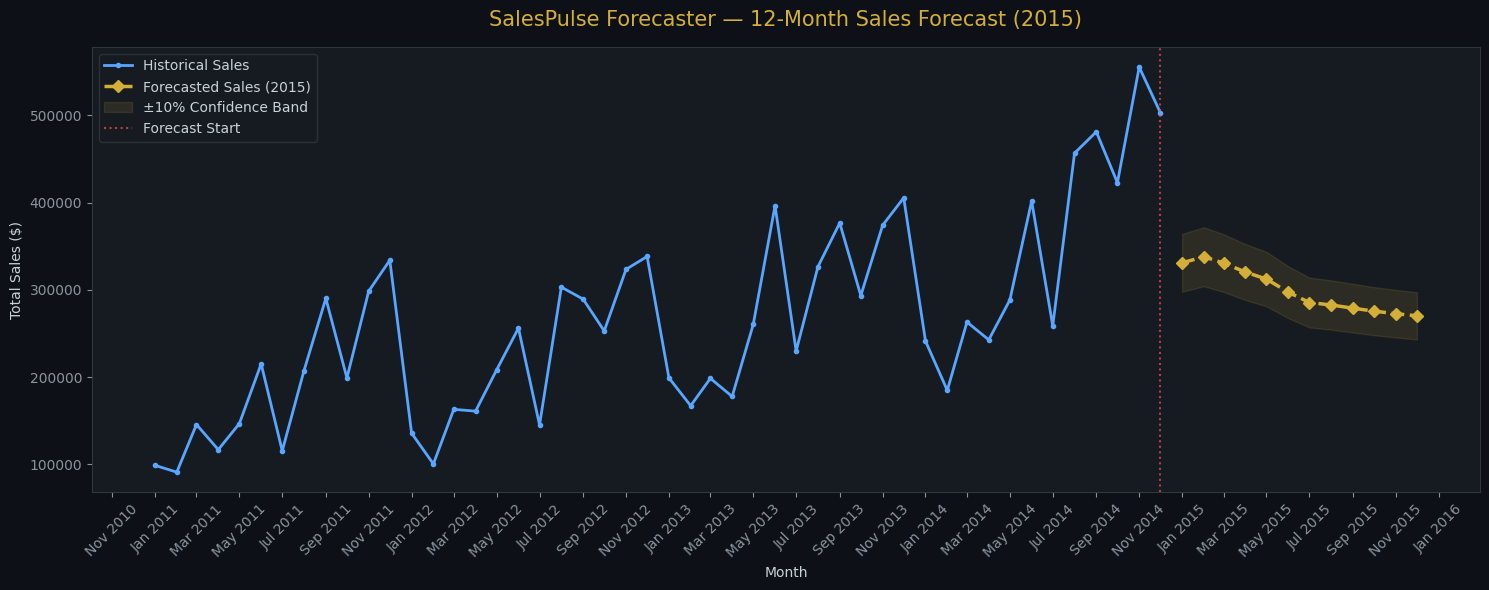

✅ Saved: assets/07_12month_forecast.png


In [20]:
# ── Forecast Visualisation ──
fig, ax = plt.subplots(figsize=(15, 6))

# Historical
ax.plot(ts.index, ts['total_sales'], color=BLUE, linewidth=2, label='Historical Sales', marker='o', markersize=3)

# Forecast
ax.plot(forecast_dates, forecast_values, color=GOLD, linewidth=2.5,
        linestyle='--', marker='D', markersize=6, label='Forecasted Sales (2015)')

# Confidence band (±10%)
ax.fill_between(forecast_dates,
                forecast_values * 0.90,
                forecast_values * 1.10,
                color=GOLD, alpha=0.12, label='±10% Confidence Band')

# Divider
ax.axvline(x=ts.index[-1], color=RED, linestyle=':', linewidth=1.5, alpha=0.7, label='Forecast Start')

ax.set_title('SalesPulse Forecaster — 12-Month Sales Forecast (2015)', fontsize=15, color=GOLD, pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Total Sales ($)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../assets/07_12month_forecast.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Saved: assets/07_12month_forecast.png")


---
## 💡 Phase 7 — Results & Business Insights

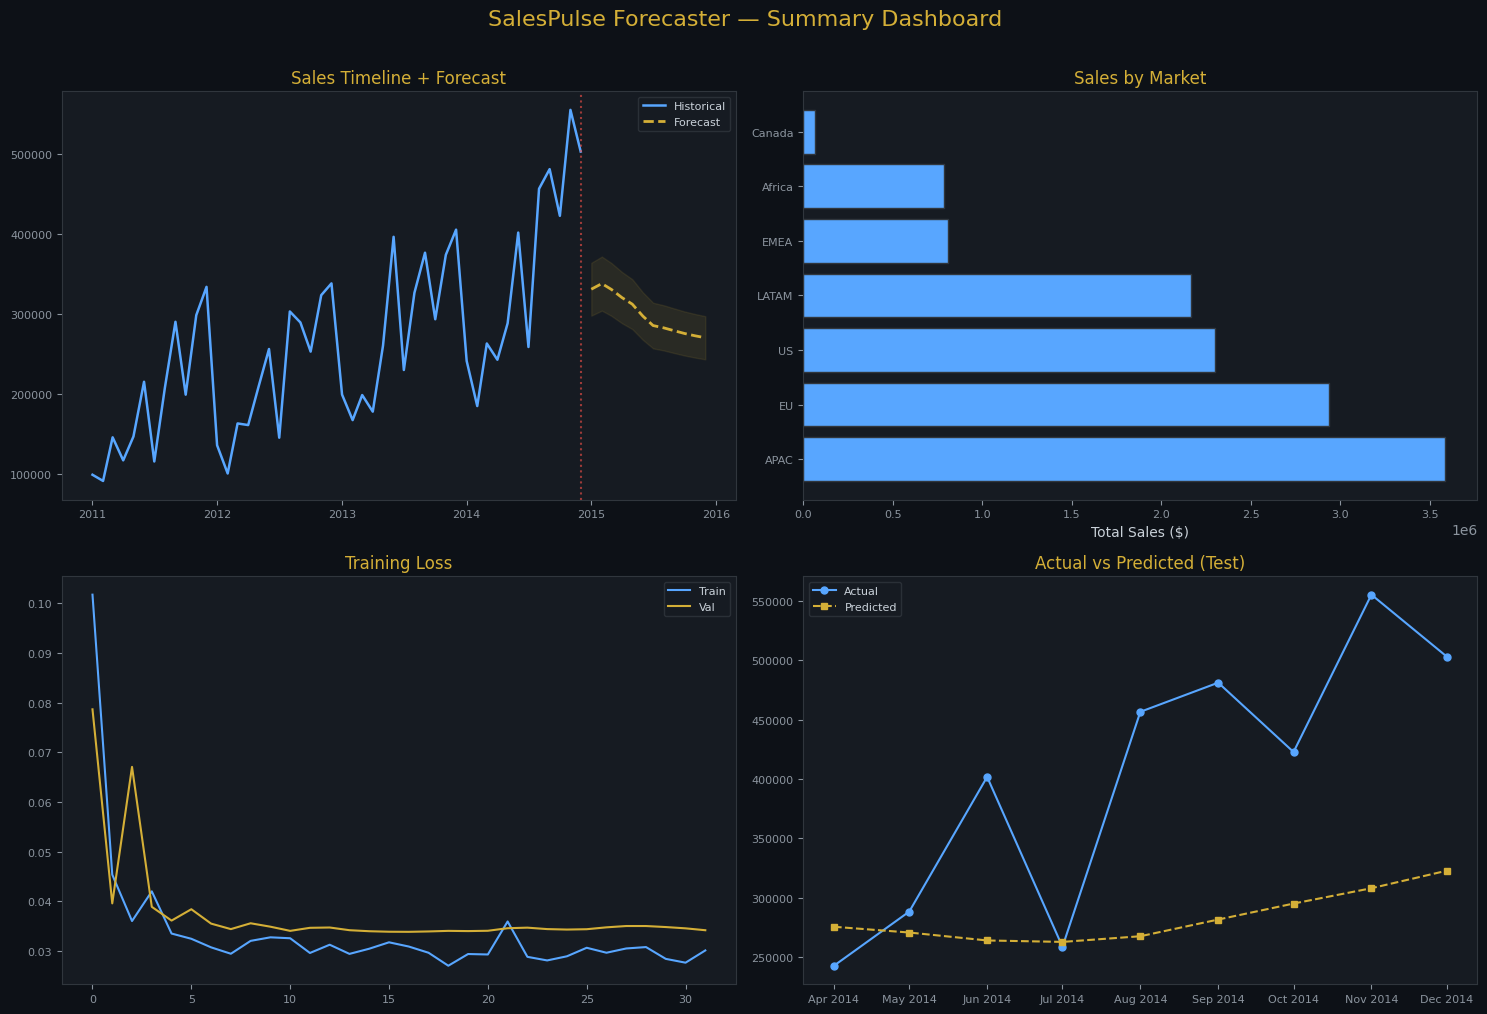

✅ Saved: assets/08_summary_dashboard.png


In [21]:
# ── Summary Dashboard ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SalesPulse Forecaster — Summary Dashboard', fontsize=16, color=GOLD, y=1.01)

# 1. Full timeline + forecast
axes[0,0].plot(ts.index, ts['total_sales'], color=BLUE, linewidth=1.8, label='Historical')
axes[0,0].plot(forecast_dates, forecast_values, color=GOLD, linewidth=2, linestyle='--', label='Forecast')
axes[0,0].fill_between(forecast_dates, forecast_values*0.9, forecast_values*1.1, color=GOLD, alpha=0.1)
axes[0,0].axvline(x=ts.index[-1], color=RED, linestyle=':', alpha=0.6)
axes[0,0].set_title('Sales Timeline + Forecast', color=GOLD)
axes[0,0].legend(fontsize=8)

# 2. Market breakdown
axes[0,1].barh(market_summary['market'], market_summary['total_sales'], color=BLUE, edgecolor='#30363D')
axes[0,1].set_title('Sales by Market', color=GOLD)
axes[0,1].set_xlabel('Total Sales ($)')

# 3. Training loss
axes[1,0].plot(history.history['loss'],     color=BLUE, label='Train')
axes[1,0].plot(history.history['val_loss'], color=GOLD, label='Val')
axes[1,0].set_title('Training Loss', color=GOLD)
axes[1,0].legend(fontsize=8)

# 4. Actual vs Predicted
axes[1,1].plot(test_dates, y_true.flatten(), color=BLUE,  label='Actual', marker='o', markersize=5)
axes[1,1].plot(test_dates, y_pred.flatten(), color=GOLD,  label='Predicted', linestyle='--', marker='s', markersize=5)
axes[1,1].set_title('Actual vs Predicted (Test)', color=GOLD)
axes[1,1].legend(fontsize=8)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for ax in axes.flatten():
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../assets/08_summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Saved: assets/08_summary_dashboard.png")


In [22]:
# ── Final Business Summary ──
print("=" * 55)
print("       📈 SALESPULSE FORECASTER — RESULTS")
print("=" * 55)
print(f"  Dataset     : Global Superstore 2011–2014")
print(f"  Records     : 51,290 transactions")
print(f"  Model       : 2-Layer LSTM (128 → 64 units)")
print(f"  Look-back   : {LOOK_BACK} months")
print()
print("  📊 MODEL PERFORMANCE")
print(f"    MAE  : ${mae:,.2f}")
print(f"    RMSE : ${rmse:,.2f}")
print(f"    MAPE : {mape:.2f}%")
print()
print("  🔮 FORECAST SUMMARY (Next 12 Months)")
print(f"    Peak Month  : {forecast_df.loc[forecast_df['forecast_sales'].idxmax(), 'month'].strftime('%b %Y')} — ${forecast_df['forecast_sales'].max():,.2f}")
print(f"    Low  Month  : {forecast_df.loc[forecast_df['forecast_sales'].idxmin(), 'month'].strftime('%b %Y')} — ${forecast_df['forecast_sales'].min():,.2f}")
print(f"    Total (12M) : ${forecast_values.sum():,.2f}")
print("=" * 55)


       📈 SALESPULSE FORECASTER — RESULTS
  Dataset     : Global Superstore 2011–2014
  Records     : 51,290 transactions
  Model       : 2-Layer LSTM (128 → 64 units)
  Look-back   : 6 months

  📊 MODEL PERFORMANCE
    MAE  : $126,231.47
    RMSE : $151,234.10
    MAPE : 27.66%

  🔮 FORECAST SUMMARY (Next 12 Months)
    Peak Month  : Feb 2015 — $337,994.09
    Low  Month  : Dec 2015 — $270,242.47
    Total (12M) : $3,595,565.25


---
## ✅ Project Complete

| Item | Detail |
|------|--------|
| **Model** | 2-Layer LSTM (128 → 64 units) + Dropout |
| **Framework** | TensorFlow / Keras |
| **Data** | Global Superstore · 51,290 records · 48 months |
| **Forecast** | 12-month ahead sales prediction |
| **SQL** | SQLite queries for aggregation & EDA |

**Author:** Venkatraman R  
[![GitHub](https://img.shields.io/badge/GitHub-venkatraman0400--blip-black?logo=github)](https://github.com/venkatraman0400-blip)  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-venkatraman0400-blue?logo=linkedin)](https://linkedin.com/in/venkatraman0400)
